# 🔤 EDA — Prénoms (`1_prenoms_detail.json`)

Exploration des données brutes de prénoms extraites par scraping.  
Fichier source : `prenoms/data/1_prenoms_detail.json`

**Plan :**
1. Chargement & aperçu général
2. Distribution des champs (couverture)
3. Distribution par sexe
4. Analyse des longueurs de textes (histoire, étymologie, provenance)
5. Bag-of-Words sur les textes d'origine
6. Détection des langues d'origine
7. Analyse des prénoms (longueur, initiales, préfixes)
8. Word Cloud

In [1]:
import json
import re
import os
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

DATA_PATH = Path('data/1_prenoms_detail.json')
print('Fichier :', DATA_PATH.resolve())

Fichier : C:\Users\JC\Documents\Sup_de_vinci\M2\NLP\Projet\prenoms\data\1_prenoms_detail.json


## 1. Chargement & aperçu général

In [2]:
with open(DATA_PATH, encoding='utf-8') as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
print(f'Nombre de prénoms : {len(df):,}')
print(f'Colonnes         : {list(df.columns)}')
df.head(3)

Nombre de prénoms : 10,005
Colonnes         : ['prenom', 'url', 'sexe', 'signification', 'caractere', 'histoire', 'etymologie', 'provenance']


,prenom,url,sexe,signification,caractere,histoire,etymologie,provenance
0,mamadou,https://www.prenoms.com/prenom-garcon/mamadou-...,garcon,"Issu de racines africaines, Mamadou signifie ""...","Sportif et énergique, Mamadou a besoin de se d...",Mamadou est un prénom dérivé de Mohamed. Ce de...,"Prénom d'origine africaine, Mamadou se traduit...",
1,taissia,https://www.prenoms.com/prenom-fille/taissia-1...,fille,,Il est difficile de résister à leur charme. Ce...,"Courtisane en Egypte au IVème siècle, Thaïs es...",grecque : le thaïs est une sorte de bandeau po...,Prénom dérivé de Taïs. d'origine grecque. Le t...
2,stephy,https://www.prenoms.com/prenom-fille/stephy-15978,fille,,Elles décoiffent et marchent au coup de coeur....,Saint Etienne (dont Stéphane est dérivé ) étai...,"grecque : de stephanos, couronné.","Diminutif de Stéphane. Vient du grec ""stephano..."


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10005 entries, 0 to 10004
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   prenom         10005 non-null  str  
 1   url            10005 non-null  str  
 2   sexe           10005 non-null  str  
 3   signification  10005 non-null  str  
 4   caractere      10005 non-null  str  
 5   histoire       10005 non-null  str  
 6   etymologie     10005 non-null  str  
 7   provenance     10005 non-null  str  
dtypes: str(8)
memory usage: 10.2 MB


## 2. Couverture des champs

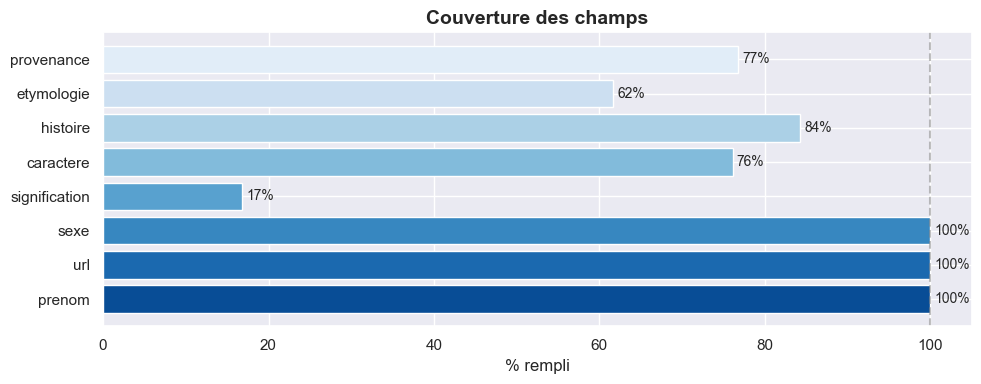

In [4]:
# Taux de remplissage par colonne
total = len(df)
coverage = {
    col: df[col].apply(lambda x: bool(x) if not isinstance(x, float) else False).sum()
    for col in df.columns
}
cov_df = pd.DataFrame({'champ': list(coverage.keys()),
                        'n_rempli': list(coverage.values())})
cov_df['pct'] = cov_df['n_rempli'] / total * 100

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(cov_df['champ'], cov_df['pct'],
               color=sns.color_palette('Blues_r', len(cov_df)))
ax.set_xlabel('% rempli')
ax.set_title('Couverture des champs', fontsize=14, fontweight='bold')
ax.axvline(100, color='gray', linestyle='--', alpha=0.5)
for bar, pct in zip(bars, cov_df['pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct:.0f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

## 3. Distribution par sexe

C:\Users\JC\AppData\Local\Temp\ipykernel_19920\1988374904.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sexe_counts.index, y=sexe_counts.values, ax=axes[1],


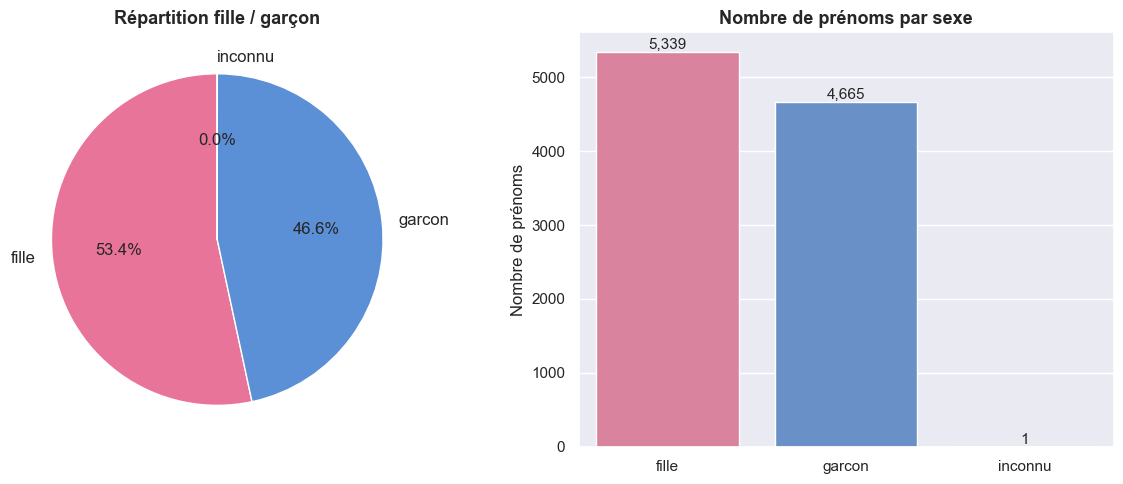

In [5]:
sexe_counts = df['sexe'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie
colors = {'fille': '#e8749a', 'garcon': '#5b8fd6', 'inconnu': '#aaa'}
pie_colors = [colors.get(s, '#ccc') for s in sexe_counts.index]
axes[0].pie(sexe_counts.values, labels=sexe_counts.index, autopct='%1.1f%%',
            colors=pie_colors, startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Répartition fille / garçon', fontsize=13, fontweight='bold')

# Bar
sns.barplot(x=sexe_counts.index, y=sexe_counts.values, ax=axes[1],
            palette=[colors.get(s,'#ccc') for s in sexe_counts.index])
axes[1].set_title('Nombre de prénoms par sexe', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Nombre de prénoms')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

## 4. Analyse des longueurs de textes (histoire, étymologie, provenance)

In [6]:
text_fields = ['histoire', 'etymologie', 'provenance', 'signification', 'caractere']

for col in text_fields:
    df[f'nb_mots_{col}'] = df[col].apply(
        lambda x: len(x.split()) if isinstance(x, str) and x else 0
    )
    df[f'nb_chars_{col}'] = df[col].apply(
        lambda x: len(x) if isinstance(x, str) and x else 0
    )

# Stats descriptives
stats = pd.DataFrame({
    col: df[f'nb_mots_{col}'].describe().round(1)
    for col in text_fields
})
print('Nombre de mots par champ (tous entrées, incl. vides) :')
display(stats)

Nombre de mots par champ (tous entrées, incl. vides) :


,histoire,etymologie,provenance,signification,caractere
count,10005.0,10005.0,10005.0,10005.0,10005.0
mean,51.6,8.7,10.6,20.0,54.9
std,31.1,16.9,8.0,46.6,63.3
min,0.0,0.0,0.0,0.0,0.0
25%,42.0,0.0,5.0,0.0,44.0
50%,52.0,5.0,11.0,0.0,56.0
75%,67.0,10.0,17.0,0.0,63.0
max,375.0,186.0,153.0,436.0,627.0


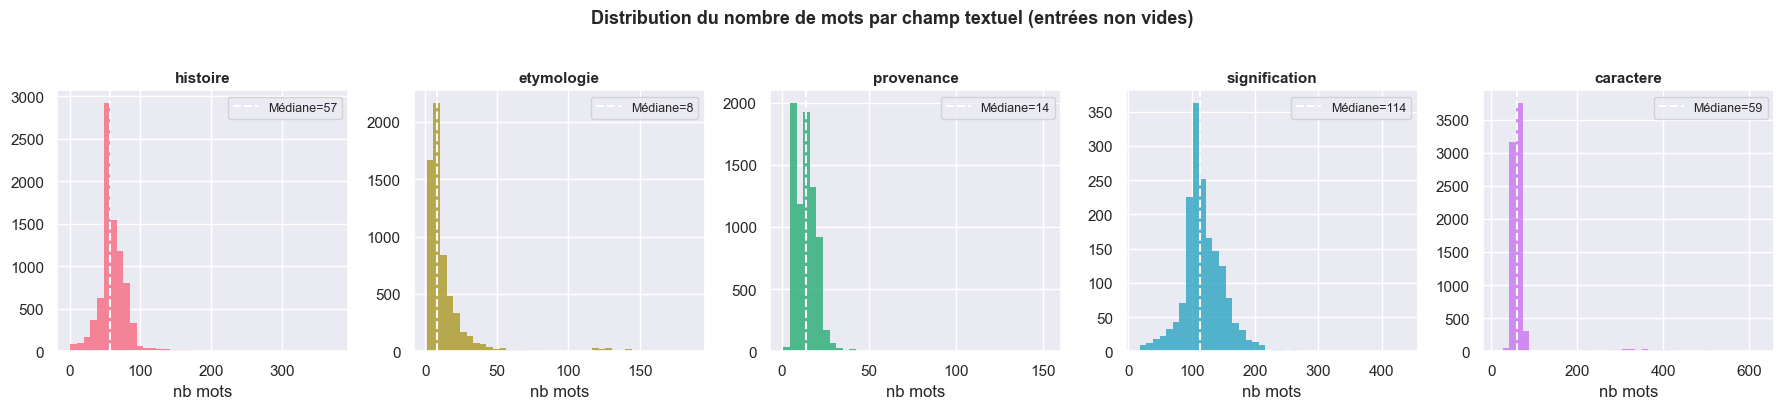

In [7]:
fig, axes = plt.subplots(1, len(text_fields), figsize=(18, 4))
palette = sns.color_palette('husl', len(text_fields))

for ax, col, color in zip(axes, text_fields, palette):
    vals = df[f'nb_mots_{col}'][df[f'nb_mots_{col}'] > 0]
    ax.hist(vals, bins=40, color=color, edgecolor='none', alpha=0.85)
    ax.axvline(vals.median(), color='white', linestyle='--', linewidth=1.5, label=f'Médiane={vals.median():.0f}')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('nb mots')
    ax.set_ylabel('')
    ax.legend(fontsize=9)

plt.suptitle('Distribution du nombre de mots par champ textuel (entrées non vides)', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\JC\AppData\Local\Temp\ipykernel_19920\2846740314.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melt_df, x='champ', y='nb_mots', palette='Set2', ax=ax,


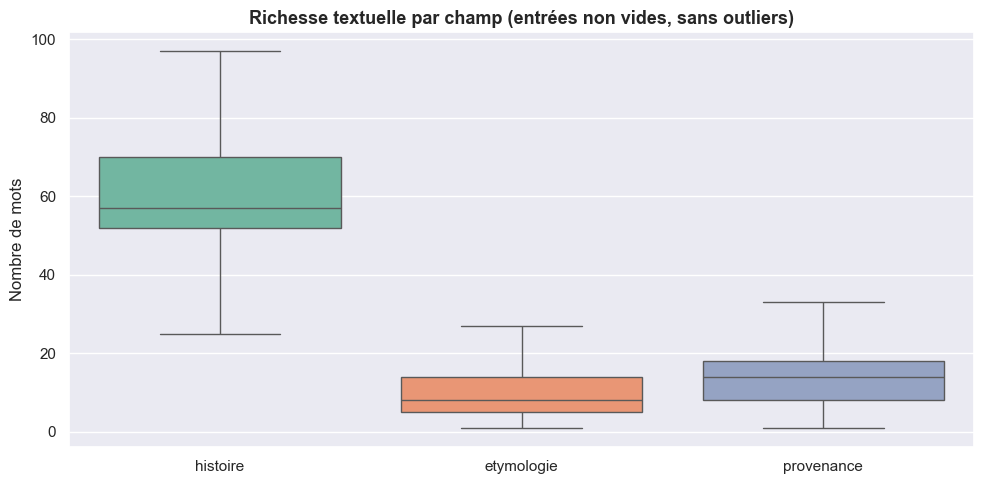

In [8]:
# Boxplot comparatif
melt_data = []
for col in ['histoire', 'etymologie', 'provenance']:
    vals = df[f'nb_mots_{col}'][df[f'nb_mots_{col}'] > 0]
    for v in vals:
        melt_data.append({'champ': col, 'nb_mots': v})
melt_df = pd.DataFrame(melt_data)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=melt_df, x='champ', y='nb_mots', palette='Set2', ax=ax,
            showfliers=False)
ax.set_title('Richesse textuelle par champ (entrées non vides, sans outliers)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Nombre de mots')
plt.tight_layout()
plt.show()

## 5. Bag-of-Words sur les textes d'origine (étymologie + histoire + provenance)

In [9]:
# Stopwords français basiques
STOPWORDS = set([
    'de', 'du', 'des', 'le', 'la', 'les', 'un', 'une', 'et', 'en', 'au', 'aux',
    'il', 'elle', 'ils', 'elles', 'se', 'sa', 'son', 'ses', 'qui', 'que', 'qu',
    'ce', 'cet', 'cette', 'ces', 'par', 'pour', 'sur', 'dans', 'avec', 'est',
    'sont', 'a', 'à', 'été', 'être', 'plus', 'très', 'ou', 'y', 'si', 'ne',
    'pas', 'mais', 'car', 'dont', 'on', 'nous', 'vous', 'leur', 'leurs', 'tout',
    'tous', 'toute', 'toutes', 'aussi', 'comme', 'même', 'bien', 'puis', 'donc',
    'from', 'the', 'of', 'and', 'in', 'is', 'to', 'a', 's', 'd', 'l', 'j', 'n'
])

def tokenize(text):
    if not isinstance(text, str):
        return []
    tokens = re.findall(r"[a-zA-ZÀ-ÿ]{3,}", text.lower())
    return [t for t in tokens if t not in STOPWORDS]

# Concaténer les 3 champs d'origine
combined_tokens = Counter()
for _, row in df.iterrows():
    text = ' '.join(filter(None, [
        row.get('etymologie') or '',
        row.get('histoire') or '',
        row.get('provenance') or ''
    ]))
    combined_tokens.update(tokenize(text))

print(f'Vocabulaire total (après stopwords) : {len(combined_tokens):,} tokens uniques')
print('\nTop 30 :')
pd.DataFrame(combined_tokens.most_common(30), columns=['mot', 'fréquence'])

Vocabulaire total (après stopwords) : 18,554 tokens uniques

Top 30 :


,mot,fréquence
0,prénom,7516
1,signifie,7225
2,fête,5719
3,vient,5299
4,saint,5170
5,origine,3113
6,dieu,2887
7,siècle,2790
8,enfants,2343
9,arabe,2337


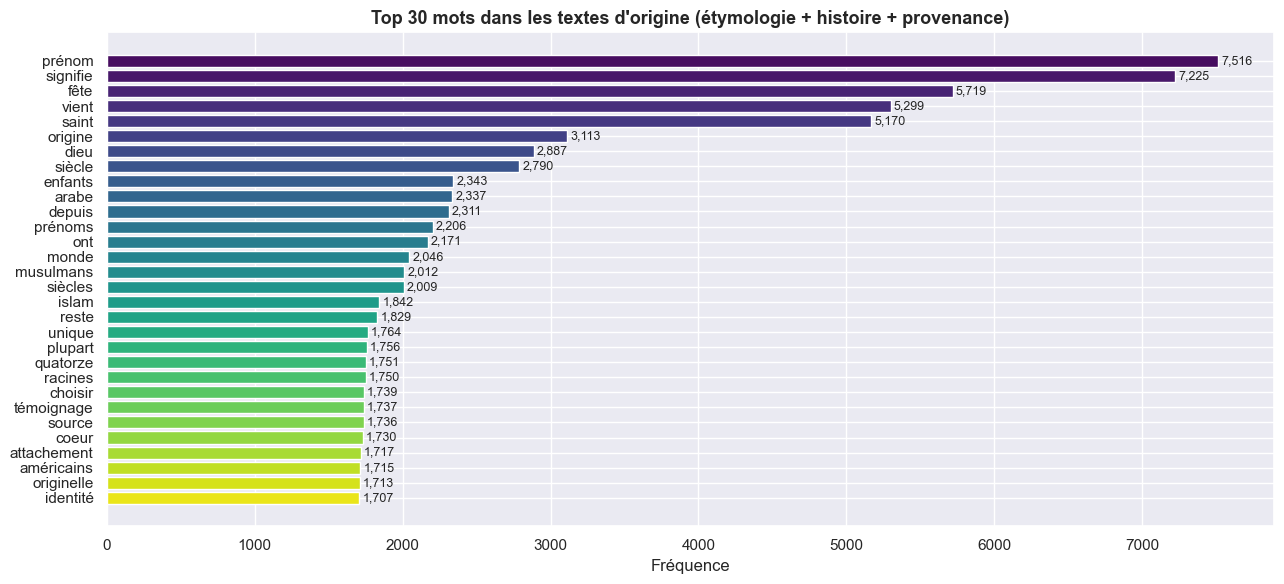

In [10]:
top_n = 30
top_words = combined_tokens.most_common(top_n)
words, freqs = zip(*top_words)

fig, ax = plt.subplots(figsize=(13, 6))
palette = sns.color_palette('viridis', top_n)
bars = ax.barh(list(words)[::-1], list(freqs)[::-1], color=palette[::-1])
ax.set_title(f'Top {top_n} mots dans les textes d\'origine (étymologie + histoire + provenance)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Fréquence')
for bar, freq in zip(bars, list(freqs)[::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{freq:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

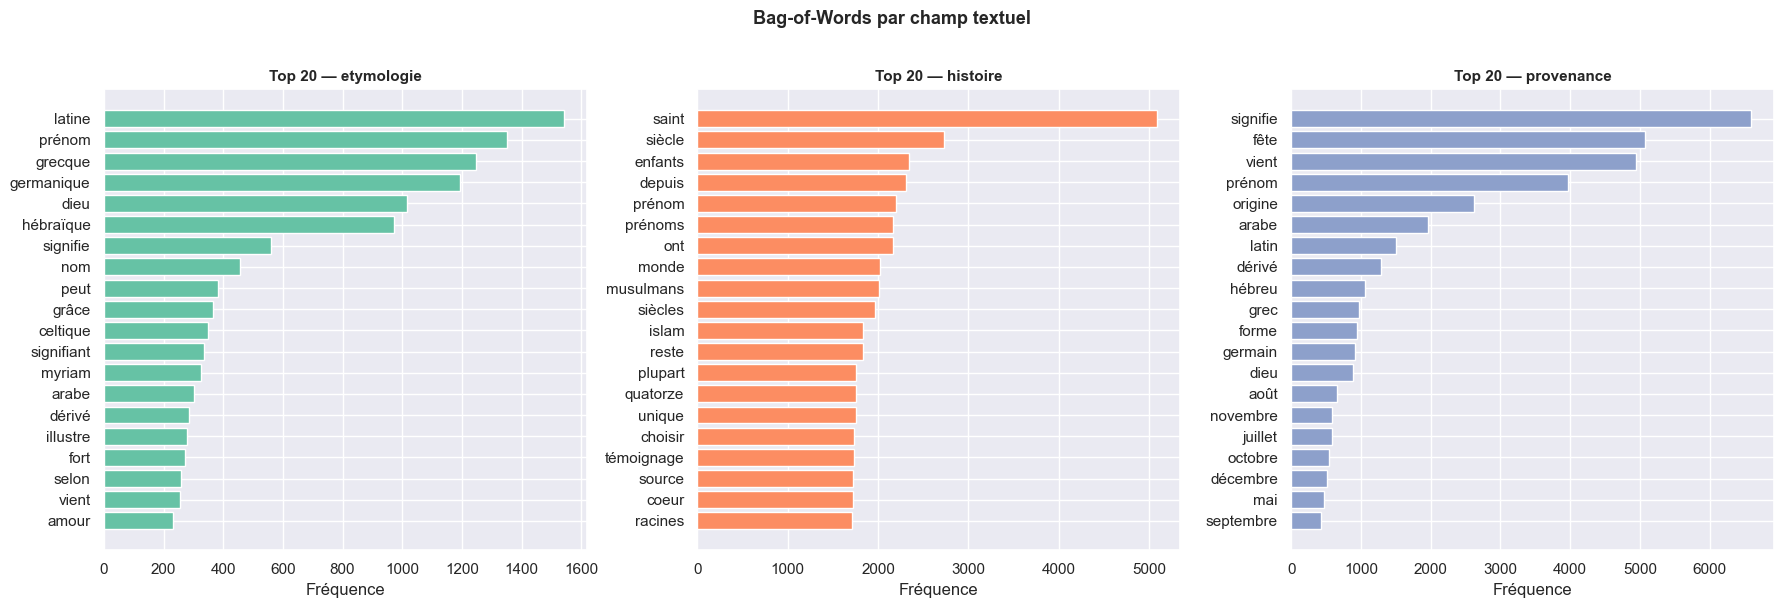

In [11]:
# BoW par champ séparément
bow_by_field = {}
for col in ['etymologie', 'histoire', 'provenance']:
    c = Counter()
    for text in df[col]:
        c.update(tokenize(str(text) if text else ''))
    bow_by_field[col] = c

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
palette = sns.color_palette('Set2', 3)

for ax, (col, bow), color in zip(axes, bow_by_field.items(), palette):
    top = bow.most_common(20)
    if not top:
        continue
    ws, fs = zip(*top)
    ax.barh(list(ws)[::-1], list(fs)[::-1], color=color)
    ax.set_title(f'Top 20 — {col}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Fréquence')

plt.suptitle('Bag-of-Words par champ textuel', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Détection des langues / origines géographiques

In [12]:
# Liste de mots-clés d'origine linguistique
LANG_KEYWORDS = {
    'latin': ['latin', 'latine', 'latins', 'romano'],
    'grec': ['grec', 'grecque', 'grèce', 'grecs', 'hellénique'],
    'hébreu': ['hébreu', 'hébraïque', 'hébreux', 'bible', 'biblique'],
    'arabe': ['arabe', 'arabes', 'arabian', 'arabo'],
    'germanique': ['germanique', 'germaniques', 'germain', 'allemand', 'vieux-haut-allemand'],
    'breton': ['breton', 'bretonne', 'bretons', 'celtique', 'celte'],
    'nordique': ['nordique', 'norrois', 'scandinave', 'viking', 'vieux-norrois'],
    'persan': ['persan', 'perse', 'iranien'],
    'sanscrit': ['sanscrit', 'sanskrit', 'hindi', 'indien'],
    'slave': ['slave', 'russe', 'polonais', 'ukrainien', 'tchèque'],
    'basque': ['basque', 'euskara'],
    'africain': ['africain', 'swahili', 'wolof', 'bambara', 'haoussa'],
}

def detect_langs(text):
    if not isinstance(text, str):
        return []
    t = text.lower()
    detected = []
    for lang, kws in LANG_KEYWORDS.items():
        if any(kw in t for kw in kws):
            detected.append(lang)
    return detected

# Combiner étymologie + histoire + provenance
lang_counter = Counter()
for _, row in df.iterrows():
    full_text = ' '.join(filter(None, [
        str(row.get('etymologie') or ''),
        str(row.get('histoire') or ''),
        str(row.get('provenance') or '')
    ]))
    langs = detect_langs(full_text)
    for l in langs:
        lang_counter[l] += 1

lang_df = pd.DataFrame(lang_counter.most_common(), columns=['langue', 'nb_prénoms'])
lang_df['pct'] = (lang_df['nb_prénoms'] / len(df) * 100).round(1)
print(lang_df.to_string(index=False))

    langue  nb_prénoms  pct
     latin        2409 24.1
     arabe        2144 21.4
      grec        1862 18.6
  africain        1712 17.1
    hébreu        1665 16.6
germanique        1617 16.2
    breton         968  9.7
     slave         147  1.5
    persan         117  1.2
  nordique          90  0.9
    basque          49  0.5
  sanscrit          22  0.2


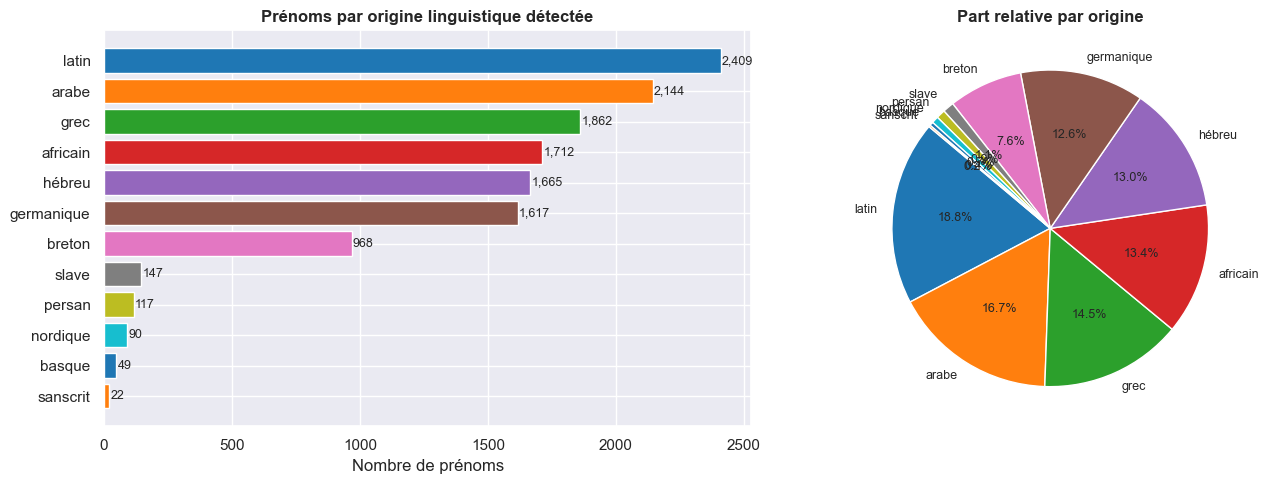

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
palette_lang = sns.color_palette('tab10', len(lang_df))
axes[0].barh(lang_df['langue'][::-1], lang_df['nb_prénoms'][::-1], color=palette_lang[::-1])
axes[0].set_title('Prénoms par origine linguistique détectée', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Nombre de prénoms')
for i, (v, l) in enumerate(zip(lang_df['nb_prénoms'][::-1], lang_df['langue'][::-1])):
    axes[0].text(v + 5, i, f'{v:,}', va='center', fontsize=9)

# Pie
axes[1].pie(lang_df['nb_prénoms'], labels=lang_df['langue'],
            autopct='%1.1f%%', colors=palette_lang, startangle=140,
            textprops={'fontsize': 9})
axes[1].set_title('Part relative par origine', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

KeyError: 'inconnu'

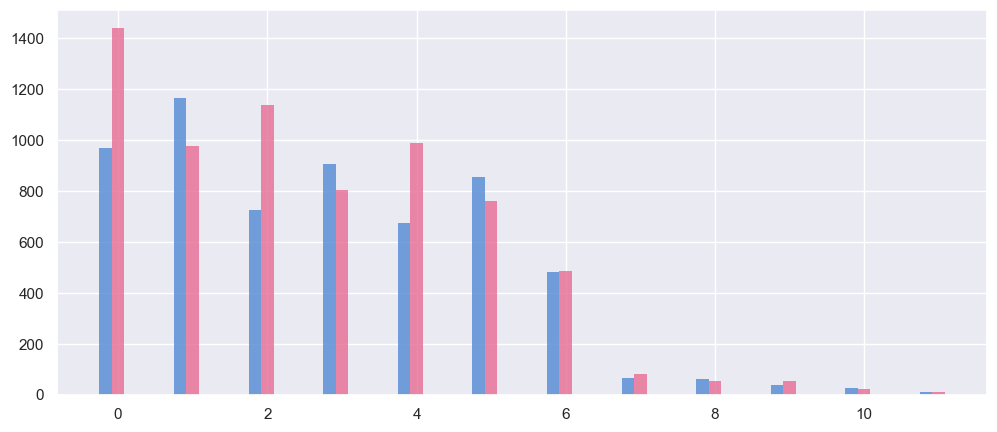

In [ ]:
# Origine par sexe
lang_by_sex = defaultdict(lambda: Counter())
for _, row in df.iterrows():
    full_text = ' '.join(filter(None, [
        str(row.get('etymologie') or ''),
        str(row.get('histoire') or ''),
        str(row.get('provenance') or '')
    ]))
    l_list = detect_langs(full_text)
    sexe = row.get('sexe', 'inconnu')
    for l in l_list:
        lang_by_sex[sexe][l] += 1

sex_lang_df = pd.DataFrame(
    {s: dict(c) for s, c in lang_by_sex.items()}
).fillna(0).astype(int)
sex_lang_df = sex_lang_df.reindex(lang_df['langue'])

sex_lang_df.plot(kind='bar', figsize=(12, 5),
                  color={'fille': '#e8749a', 'garcon': '#5b8fd6', 'inconnu': '#ffffff'},
                  edgecolor='none', alpha=0.85)
plt.title('Origines linguistiques par sexe', fontsize=13, fontweight='bold')
plt.xlabel('')
plt.ylabel('Nombre de prénoms')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Sexe')
plt.tight_layout()
plt.show()

## 7. Analyse des prénoms eux-mêmes (longueur, initiales, préfixes)

In [ ]:
df['longueur'] = df['prenom'].str.len()
df['initiale'] = df['prenom'].str[0].str.upper()
df['prenom_clean'] = df['prenom'].str.replace(r'[^a-zA-ZÀ-ÿ]', '', regex=True)

print('Longueur des prénoms :')
print(df['longueur'].describe().round(2))
print(f'\nPrénom le plus court : {df.loc[df.longueur.idxmin(), "prenom"]} ({df.longueur.min()} chars)')
print(f'Prénom le plus long  : {df.loc[df.longueur.idxmax(), "prenom"]} ({df.longueur.max()} chars)')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution longueurs par sexe
for sexe, color in [('fille', '#e8749a'), ('garcon', '#5b8fd6')]:
    subset = df[df.sexe == sexe]['longueur']
    axes[0].hist(subset, bins=range(1, 20), alpha=0.65, color=color, label=sexe, edgecolor='none')
axes[0].set_title('Distribution des longueurs de prénoms', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Nombre de lettres')
axes[0].set_ylabel('Nombre de prénoms')
axes[0].legend()

# Initiales
init_counts = df['initiale'].value_counts().sort_index()
axes[1].bar(init_counts.index, init_counts.values,
            color=sns.color_palette('viridis', len(init_counts)))
axes[1].set_title('Fréquence des initiales', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Lettre')
axes[1].set_ylabel('Nombre de prénoms')
axes[1].tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# Top 20 initiales par sexe
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, sexe, color in zip(axes, ['fille', 'garcon'], ['#e8749a', '#5b8fd6']):
    sub = df[df.sexe == sexe]['initiale'].value_counts().head(10)
    ax.bar(sub.index, sub.values, color=color, alpha=0.85)
    ax.set_title(f'Top initiales — {sexe}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Lettre')
    ax.set_ylabel('Nombre de prénoms')
plt.tight_layout()
plt.show()

In [ ]:
# Terminaisons fréquentes (2 derniers chars)
df['suffix2'] = df['prenom'].str[-2:]
df['suffix3'] = df['prenom'].str[-3:]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, color in zip(axes, ['suffix2', 'suffix3'], ['#7bcfa0', '#a07bcf']):
    top = df[col].value_counts().head(15)
    ax.barh(top.index[::-1], top.values[::-1], color=color, alpha=0.85)
    ax.set_title(f'Top terminaisons ({col[-1]} chars)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Fréquence')
plt.tight_layout()
plt.show()

In [ ]:
# Prénoms composés (contenant un tiret ou espace)
df['compose'] = df['prenom'].str.contains(r'[-\s]', regex=True)
compo_counts = df['compose'].value_counts()
print('Prénoms composés :', compo_counts.get(True, 0))
print('Prénoms simples  :', compo_counts.get(False, 0))

fig, ax = plt.subplots(figsize=(6, 4))
ax.pie([compo_counts.get(False, 0), compo_counts.get(True, 0)],
       labels=['Simple', 'Composé'], autopct='%1.1f%%',
       colors=['#5b8fd6', '#f0a060'], startangle=90)
ax.set_title('Prénoms simples vs composés', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Word Cloud des textes d'origine
> *Nécessite `wordcloud` : `pip install wordcloud`*

In [ ]:
try:
    from wordcloud import WordCloud

    # Texte global
    all_text = ' '.join(
        str(row.get('etymologie') or '') + ' ' +
        str(row.get('histoire') or '') + ' ' +
        str(row.get('provenance') or '')
        for _, row in df.iterrows()
    )

    wc = WordCloud(
        width=1200, height=500, background_color='white',
        stopwords=STOPWORDS, max_words=200,
        colormap='viridis', collocations=False
    ).generate(all_text)

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title('Word Cloud — Textes d\'origine (étymologie + histoire + provenance)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Par sexe
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for ax, sexe, cmap in zip(axes, ['fille', 'garcon'], ['RdPu', 'Blues']):
        subset = df[df.sexe == sexe]
        text_s = ' '.join(
            str(row.get('etymologie') or '') + ' ' + str(row.get('histoire') or '')
            for _, row in subset.iterrows()
        )
        wc_s = WordCloud(
            width=700, height=400, background_color='white',
            stopwords=STOPWORDS, max_words=100,
            colormap=cmap, collocations=False
        ).generate(text_s)
        ax.imshow(wc_s, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f'Word Cloud — {sexe}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

except ImportError:
    print('⚠️  wordcloud non installé. Exécuter : pip install wordcloud')

## 9. Analyse des bigrammes

In [ ]:
from itertools import islice

def bigrams(tokens):
    it1 = iter(tokens)
    it2 = iter(tokens)
    next(it2, None)
    return [(a, b) for a, b in zip(it1, it2)]

bigram_counter = Counter()
for _, row in df.iterrows():
    text = ' '.join(filter(None, [
        str(row.get('etymologie') or ''),
        str(row.get('histoire') or '')
    ]))
    toks = tokenize(text)
    bigram_counter.update(bigrams(toks))

top_bi = bigram_counter.most_common(20)
bi_labels = [f'{a} {b}' for a, b in [x[0] for x in top_bi]]
bi_freqs  = [x[1] for x in top_bi]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(bi_labels[::-1], bi_freqs[::-1], color=sns.color_palette('magma', 20)[::-1])
ax.set_title('Top 20 bigrammes (étymologie + histoire)', fontsize=13, fontweight='bold')
ax.set_xlabel('Fréquence')
plt.tight_layout()
plt.show()

## 10. Récapitulatif statistiques clés

In [ ]:
print('='*55)
print('  RÉCAPITULATIF — 1_prenoms_detail.json')
print('='*55)
print(f'  Nombre total de prénoms      : {len(df):>8,}')
print(f'  Prénoms féminins             : {(df.sexe=="fille").sum():>8,}')
print(f'  Prénoms masculins            : {(df.sexe=="garcon").sum():>8,}')
print(f'  Longueur moyenne             : {df.longueur.mean():>8.1f} chars')
print(f'  Prénoms composés             : {df.compose.sum():>8,}')
print(f'  Couverture étymologie         : {df.etymologie.notna().sum() if "etymologie" in df.columns else 0:>8,}')
print(f'  Couverture histoire           : {df.histoire.notna().sum() if "histoire" in df.columns else 0:>8,}')
print(f'  Couverture provenance         : {df.provenance.notna().sum() if "provenance" in df.columns else 0:>8,}')
print(f'  Vocabulaire unique (BoW)      : {len(combined_tokens):>8,}')
print('='*55)